# Checking for Errors Beckmann rate Data

This workbook contains the code and imports the data to explore the Beckmann hammett plot.

the data being plotted is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 

I will be plotting differentials between digitized data and tabular data to compare the plots in the paper to the given values.

I have reused previous notebooks and just added what I needed. There is lots of code here that is not used. Its also a hack job and is not elegant. But it works.

## Setup Tools and Read Substituent Data Table

Here the data table for Steric substitutent constants is read in and processed. Also the libraries are imported and any functions defined

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

github = False

if github == True:
    github_location = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_21/data/"
    github_location_styles = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
    github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/data/"
else:  
    github_location = "data/"
    github_location_styles = "../../styles/"
    github_location_LFER_tables = "~/github/LFER-QSAR/data/"

style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"
plt.style.use(github_location_styles + style_file)        




In [70]:
#################################################################
### Load in table of sigma values and fill in any blanks.     ###
#################################################################

# a function to fill in sigma for empty spaces in s+ and s- ###
def fill_sigma(df):     
    for z in df.index:                                  # loop over all rows
        if np.isnan(df.loc[z,"s_plus"]):                # check if s_plus is NaN
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]      # if so, fill it with sigma value
        if np.isnan(df["s_minus"][z]):                  # check if s_minus is NaN
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]     # if so, fill it with sigma value
    return(df)

### Read data set. The fields are separated by commas; comments are enabled  

#LFER_file = "Taft_Es_Williams.csv"        # Choose a data set to load
#LFER_file = "LFER_HanschLeoTaft.csv"   
LFER_file = "LFER_Williams.csv"            # This had values for a few ortho substituents

data_set = pd.read_csv(github_location_LFER_tables + LFER_file,
                        delimiter = ",", 
                        skipinitialspace=True, 
                        index_col="Substituent", 
                        comment = "#") 
#display(data_set)

########################################################
### Fill across sigma values and select substituents ###
########################################################

data_set=fill_sigma(data_set)
#display(data_set)

###############################
### Remove unneeded columns ###
###############################

if LFER_file == "LFER_HanschLeoTaft.csv":
    data_set.drop(labels = ["TABLE V", "TABLE I"],      #Trim "LFER_HanschLeoTaft.csv" data
    axis = 1,
    inplace = True)
elif LFER_file == "LFER_Williams.csv":
    data_set.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
    axis = 1,
    inplace = True)
else:
    print("ERROR: No filename")

### Sort by Steric Size and display -- if needed

#data_set.sort_values(by=['sigma'], inplace=True)
#data_set.sort_values(by=["E'(s)"], inplace=True)

print(data_set)    # This displays the full table of substituent parameters

             sigma  s_plus  s_minus
Substituent                        
m-Br          0.39    0.39     0.39
p-Br          0.23    0.15     0.25
m-C6H5        0.06    0.06     0.06
p-C6H5       -0.01    0.02    -0.18
m-CCCH3       0.10    0.10     0.10
...            ...     ...      ...
p-C(CH3)3    -0.20   -0.26    -0.13
m-C(CH3)3    -0.10   -0.10    -0.10
3,5-CH3      -0.12   -0.12    -0.12
3,4,5-CH3    -0.26   -0.43    -0.29
3,4-CH3      -0.20   -0.37    -0.23

[76 rows x 3 columns]


## Read Experimental Data for Acid Hydrolysis
Here the data from the publication is read in. It had been saved in a csv file. the data is from...

"Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *J. Chem. Soc. B*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 

In [71]:
############################################
### Read in data from literature example ###
############################################

datafile = "Table1and2All.csv"

Beckmann_data = pd.read_csv(github_location + datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#")
Beckmann_data["kobs"] = 10**(-4) * Beckmann_data["kobs"]
Beckmann_data["log_k"] = np.log10(Beckmann_data["kobs"])


#display(df.head())

# filter dataframe for rows where %H2SO4 is 98.2 and TempC is 80
Beckmann_data = Beckmann_data[(Beckmann_data['%H2SO4'] == 98.2) & (Beckmann_data['TempC'] == 80)]
display(Beckmann_data)

,Name,%H2SO4,TempC,kobs,log_k
Substituent,,,,,
H,Hydrogen,98.2,80.0,0.001700,-2.769551
m-Br,m-Bromo,98.2,80.0,0.000720,-3.142668
p-Br,p-Bromo,98.2,80.0,0.001170,-2.931814
m-Cl,m-Chloro,98.2,80.0,0.000720,-3.142668
p-Cl,p-Chloro,98.2,80.0,0.001170,-2.931814
m-F,m-Fluoro,98.2,80.0,0.000630,-3.200659
p-F,p-Fluoro,98.2,80.0,0.001380,-2.860121
m-I,m-Iodo,98.2,80.0,0.000880,-3.055517
p-I,p-Iodo,98.2,80.0,0.001230,-2.910095


## Combine Data Sets

Both data sets are indexed by "Substituent". The code below will combine the two data sets according to "Substituent" and take the intersection of the sets.

## Calculations

We need the log of the rate. Also we will convert the rate to SI units. The current units are in $10^{-4} s^{-1}$. We will convert to $s^{-1}$ by multiplying by $10^4$.


In [72]:
##################################################
### Combine data sets using the index column.  ###
### Data lines that share an index column will ###
### be combined, all other ignored.            ###
##################################################

combined_data = pd.concat([Beckmann_data, data_set], axis=1, join="inner")
#display(combined_data_acid)

#########################################################################
### Perform calculations on columns and add new columns with results  ###
#########################################################################

#combined_data["k"] = combined_data["k"] * 10**(-6)
##combined_data["log_k"] = np.log10(combined_data["k"])

#combined_data.drop(labels = ["o-NO2","o-Cl","o-CH3"], axis = 0, inplace = True)  # remove the "o-NO2" data point.
#combined_data.drop(labels = ["p-OH"], axis = 0, inplace = True)  # remove the "o-NO2" data point.

display(combined_data.head())


,Name,%H2SO4,TempC,kobs,log_k,sigma,s_plus,s_minus
Substituent,,,,,,,,
H,Hydrogen,98.2,80.0,0.00170,-2.769551,0.00,0.00,0.00
m-Br,m-Bromo,98.2,80.0,0.00072,-3.142668,0.39,0.39,0.39
p-Br,p-Bromo,98.2,80.0,0.00117,-2.931814,0.23,0.15,0.25
m-Cl,m-Chloro,98.2,80.0,0.00072,-3.142668,0.37,0.37,0.37
p-Cl,p-Chloro,98.2,80.0,0.00117,-2.931814,0.23,0.11,0.19


## Combine Digitized Data with Sigma Data Set

Both data sets are indexed by "Substituent". The code below will combine the two data sets according to "Substituent" and take the intersection of the sets.

In [73]:
############################################
### Read in data from literature example ###
############################################

datafile = "Figure_2_Picked.csv"

Beckmann_data2 = pd.read_csv(github_location + datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 

Beckmann_data2.rename(columns={"sigma":"sigma_2", 
                               "log(kobs /s-1)":"log(kobs /s-1)_2"}, 
                               inplace=True)


# merge dataframes by index and put new columns to the right 
combined_data2 = pd.concat([combined_data, Beckmann_data2], axis=1, join="inner")
combined_data2["diff_sigma"] = combined_data2["sigma_2"] - combined_data2["sigma"]
#combined_data2["diff_sigma"] = combined_data2["sigma_2"] - combined_data2["s_plus"]
combined_data2["diff_log_k"] = combined_data2["log(kobs /s-1)_2"] - combined_data2["log_k"] 

display(combined_data2) 


,Name,%H2SO4,TempC,kobs,log_k,sigma,s_plus,s_minus,sigma_2,log(kobs /s-1)_2,diff_sigma,diff_log_k
Substituent,,,,,,,,,,,,
H,Hydrogen,98.2,80.0,0.001700,-2.769551,0.00,0.00,0.00,-0.000,-2.766,-0.000,0.003551
m-Br,m-Bromo,98.2,80.0,0.000720,-3.142668,0.39,0.39,0.39,0.409,-3.129,0.019,0.013668
p-Br,p-Bromo,98.2,80.0,0.001170,-2.931814,0.23,0.15,0.25,0.230,-2.924,0.000,0.007814
m-Cl,m-Chloro,98.2,80.0,0.000720,-3.142668,0.37,0.37,0.37,0.360,-3.134,-0.010,0.008668
p-Cl,p-Chloro,98.2,80.0,0.001170,-2.931814,0.23,0.11,0.19,0.230,-2.924,0.000,0.007814
m-F,m-Fluoro,98.2,80.0,0.000630,-3.200659,0.34,0.34,0.34,0.335,-3.199,-0.005,0.001659
p-F,p-Fluoro,98.2,80.0,0.001380,-2.860121,0.06,-0.07,-0.03,0.066,-2.857,0.006,0.003121
m-I,m-Iodo,98.2,80.0,0.000880,-3.055517,0.35,0.35,0.35,0.354,-3.058,0.004,-0.002483
p-I,p-Iodo,98.2,80.0,0.001230,-2.910095,0.18,0.14,0.27,0.177,-2.906,-0.003,0.004095


## Figure 6

the code below will make figure 6

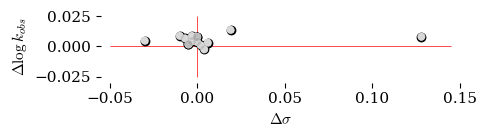

In [74]:
from scipy.stats import linregress
import matplotlib

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

r = 0.0
x = combined_data2["diff_sigma"]
y =  combined_data2["diff_log_k"]

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.5))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

#########################################
### Plot the data and the line fit.   ###
#########################################

ax.scatter(x,y, s = 32, color="white",  edgecolors = "black", zorder=2, linewidths=1.4)
ax.scatter(x,y, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
ax.scatter(x,y, s = 32, color="gray",  edgecolors = "none", alpha = 0.3, zorder=4)

############################
### Set labels and scale ###
############################

xlabel_string = r"$\Delta\sigma$"
#xlabel_string = r"$\Delta\sigma^+$"
#xlabel_string = r"$\sigma + r(\sigma^+-\sigma)$, $r = 0.6$"

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$\Delta\log{k_{obs}}$", 
          xlabel=xlabel_string,                
          xlim=[-.055,.15],                  
          ylim=[-.03,.03],
          xticks = ( -0.05,0, 0.05, 0.10,0.15),
#          xlim=[-.55,.10],                  
#          ylim=[-.03,.03],
#          xticks = ( -0.5,-0.4,-0.3,-0.2,-0.1,0, 0.10),
         )

if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(combined_data.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center

ax.hlines(y=0, xmin=-0.05, xmax=0.145, 
          colors='red', linestyles='solid', 
          zorder=0, linewidth=0.5)
ax.vlines(x=0, ymin=-0.025, ymax=0.025, 
          colors='red', linestyles='solid', 
          zorder=0, linewidth=0.5)


fig.savefig("plots/Fig_6_sigmadiffs.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots




## Figure 7

The code below will make figure 7. It is identical to the code above but uses $\sigma^+$ and data digitized from figure 3 in the paper.

In [75]:
############################################
### Read in data from literature example ###
############################################

datafile = "Figure_3_Picked.csv"

Beckmann_data2 = pd.read_csv(github_location + datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 

Beckmann_data2.rename(columns={"sigma":"sigma_2", 
                               "log(kobs /s-1)":"log(kobs /s-1)_2"}, 
                               inplace=True)

# merge dataframes by index and put new columns to the right 
combined_data2 = pd.concat([combined_data, Beckmann_data2], axis=1, join="inner")
combined_data2["diff_sigma"] = combined_data2["sigma_2"] - combined_data2["s_plus"]
combined_data2["diff_log_k"] = combined_data2["log(kobs /s-1)_2"] - combined_data2["log_k"] 

display(combined_data2) 


,Name,%H2SO4,TempC,kobs,log_k,sigma,s_plus,s_minus,sigma_2,log(kobs /s-1)_2,diff_sigma,diff_log_k
Substituent,,,,,,,,,,,,
H,Hydrogen,98.2,80.0,0.001700,-2.769551,0.00,0.00,0.00,-0.003,-2.763,-0.003,0.006551
m-Br,m-Bromo,98.2,80.0,0.000720,-3.142668,0.39,0.39,0.39,0.402,-3.135,0.012,0.007668
p-Br,p-Bromo,98.2,80.0,0.001170,-2.931814,0.23,0.15,0.25,0.156,-2.929,0.006,0.002814
m-Cl,m-Chloro,98.2,80.0,0.000720,-3.142668,0.37,0.37,0.37,0.402,-3.135,0.032,0.007668
p-Cl,p-Chloro,98.2,80.0,0.001170,-2.931814,0.23,0.11,0.19,0.107,-2.929,-0.003,0.002814
m-F,m-Fluoro,98.2,80.0,0.000630,-3.200659,0.34,0.34,0.34,0.351,-3.196,0.011,0.004659
p-F,p-Fluoro,98.2,80.0,0.001380,-2.860121,0.06,-0.07,-0.03,-0.075,-2.857,-0.005,0.003121
m-I,m-Iodo,98.2,80.0,0.000880,-3.055517,0.35,0.35,0.35,0.354,-3.055,0.004,0.000517
p-I,p-Iodo,98.2,80.0,0.001230,-2.910095,0.18,0.14,0.27,0.132,-2.893,-0.008,0.017095


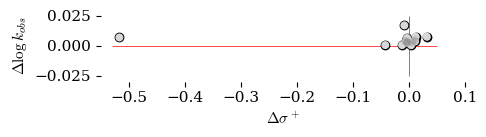

In [76]:
from scipy.stats import linregress
import matplotlib

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

x = combined_data2["diff_sigma"]
y =  combined_data2["diff_log_k"]

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.5))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

#########################################
### Plot the data and the line fit.   ###
#########################################

ax.scatter(x,y, s = 32, color="white",  edgecolors = "black", zorder=2, linewidths=1.4)
ax.scatter(x,y, s = 32, color="white",  edgecolors = "none", alpha = 1, zorder=2)
ax.scatter(x,y, s = 32, color="gray",  edgecolors = "none", alpha = 0.3, zorder=4)


############################
### Set labels and scale ###
############################

#xlabel_string = r"$\Delta\sigma$"
xlabel_string = r"$\Delta\sigma^+$"
#xlabel_string = r"$\sigma + r(\sigma^+-\sigma)$, $r = 0.6$"

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$\Delta\log{k_{obs}}$", 
          xlabel=xlabel_string,                
#          xlim=[-.055,.15],                  
#          ylim=[-.03,.03],
#          xticks = ( -0.05,0, 0.05, 0.10),
          xlim=[-.55,.10],                  
          ylim=[-.03,.03],
          xticks = ( -0.5,-0.4,-0.3,-0.2,-0.1,0, 0.10),
         )

if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(combined_data.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center

ax.hlines(y=0, xmin=-0.53, xmax=0.05, 
          colors='red', linestyles='solid', 
          zorder=0, linewidth=0.5)
ax.vlines(x=0, ymin=-0.025, ymax=0.025, 
          colors='red', linestyles='solid', 
          zorder=0, linewidth=0.5)


fig.savefig("plots/Fig_7_sigmaplusdiffs.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots


